#### Problem 1
##### Proving constant Jacobi integral value

In [ ]:
import numpy as np
from orbit_package.orbit_package import Orbit
from orbit_package.numerical import Integrator,ForcingFunction
from orbit_package.graphing_utils import Graph
import matplotlib.pyplot as plt

# Instantiation of orbit object
orb = Orbit()

# Instantiating all obejects
integrate = Integrator()
ff = ForcingFunction()
gr = Graph()

other = {"mu":0.1}
period = 100
tspan = [0,period]
integration_time = np.linspace(0,2*int(period),int(2*int(period)/60))

X0 = [np.array([0.5,0.5,0,-0.1,0.1,0]),np.array([0.1,-0.5,0,0,0.1,0]),np.array([0,1,0,0.1,0.4,0])]
for X in X0:
    # Integrating
    print(f'X0 = {X}')
    t,x = integrate.ode45(ff.cr3bp_nodyn,X,tspan,other)

    # Creating ephemeris object, plotting
    eph = integrate.eph_from_propagation_results(t,x,"CR3BP_NODYN")

    # Determining the jacobi integral to solve, calculating in eph
    from orbit_package.threebp_objects import Cr3bp
    cr3bp = Cr3bp()
    gr.plot_eph_jacobi(eph,cr3bp.J_planar,other['mu'])



#### Problem 2
##### Finding the Equilibrium Points as a function of mu

In [ ]:
from orbit_package.threebp_objects import Cr3bp
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import root_scalar

cr3bp = Cr3bp()

x = np.linspace(-4,4,600)
y = 0
z = 0
mu_list = np.linspace(1e-6,0.5,10)
x0_list = [-1,0,1]
Vx_list = []
solutions = []
for mu in  mu_list:
    # Solving for solution curve, root func
    Vx = cr3bp.pVpx(x,y,z,mu)
    Vx_list.append(Vx)
    root_func = lambda l: cr3bp.pVpx(l,0,0,mu)

    # Finding roots with three different x0 values
    rlist = []
    for x0 in x0_list:
        root = root_scalar(root_func,x0=x0,method='newton')
        rlist.append(root['root'])
    solutions.append(rlist)


# for i in range(len(Vx_list)):
#     plt.plot(x,Vx_list[i],label=f'mu={round(mu_list[i],4)}')
#     plt.scatter(solutions[i][0],0)
#     plt.scatter(solutions[i][1],0)
#     plt.scatter(solutions[i][2],0)
# plt.title('Root Finding Solution For Different Values of mu')
# plt.xlabel('x')
# plt.ylabel('Vx')
# plt.ylim([-3,3])
# plt.grid()
# plt.show()

x1 = [sol[0] for sol in solutions]
x2 = [sol[1] for sol in solutions]
x3 = [sol[2] for sol in solutions]
plt.plot(mu_list,x1,label='L3')
plt.plot(mu_list,x2,label='L1')
plt.plot(mu_list,x3,label='L2')
plt.grid()
plt.xlabel('mu')
plt.ylabel('Equilibrium x Value')
plt.title('Equilibrium Point Change Due to mu')
plt.legend()
plt.show()





#### Problem 3
##### Checking Stability and Instability of L4 and L5 for mu_stable and mu_unstable

In [ ]:
import numpy as np
from orbit_package.orbit_package import Orbit
from orbit_package.numerical import Integrator,ForcingFunction
from orbit_package.graphing_utils import Graph
import matplotlib.pyplot as plt
gr = Graph()
ff = ForcingFunction()
integrate = Integrator()
all_eph34 = []
all_x034 = []
run_case = []
run = False
# Stability mu values
mu_crit = 0.5*(1-np.sqrt(23/27))
delta = 0.03
mu_stable = mu_crit - delta
mu_unstable = mu_crit + delta

################################################################
# Checking the stability of L4/L5 for mu_stable
################################################################

# Coordinates of L4,L5
xE = 0.5*(1-2*mu_stable) # x coordinate of L4,L5
yEu = np.sqrt(3)/2 # Upper point (L4)
yEl = -yEu         # Lower point (L5)
delta_r = 0.000001

# Checking Stability of L4
X0_list = [np.array([xE+delta_r,yEu+delta_r,0,0.1,0,0]),np.array([xE-delta_r,yEu,0.1,0,0,0]),np.array([xE,yEu-delta_r,0,0,0,0])]
other = {'mu':mu_stable}
tspan = [0,20*np.pi]
tval = np.linspace(tspan[0],tspan[1],500)

eq_point = [[xE,yEu,0]]
point_names = ['L4']
# Iterating through several initial conditions
for X in X0_list:
    # Integrating
    print(f'X0 = {X}')
    run_case.append('L4 Stability Test (mu=mu_stable) (Question 3)')
    t,x = integrate.ode45(ff.cr3bp_nodyn,X,tspan,other,rtol=1e-13,method='DOP853',tval=tval)

    # Creating ephemeris object, plotting
    eph = integrate.eph_from_propagation_results(t,x,"CR3BP_NODYN")
    all_eph34.append(eph)
    all_x034.append(X)
    # gr.plot_eph_r_norm(eph)
    # gr.plot_eph_pos_vector_2D(eph,points=eq_point,point_names=point_names)

# Checking Stability of L5
X0_list = [np.array([xE+delta_r,yEl+delta_r,0,0.1,0,0]),np.array([xE-delta_r,yEl,0.1,0,0,0]),np.array([xE,yEl-delta_r,0,0,0,0])]
other = {'mu':mu_stable}
tspan = [0,20*np.pi]
tval = np.linspace(tspan[0],tspan[1],500)

eq_point = [[xE,yEl,0]]
point_names = ['L5']
# Iterating through several initial conditions
for X in X0_list:
    # Integrating
    print(f'X0 = {X}')
    run_case.append('L5 Stability Test  (mu=mu_stable) (Question 3)')
    t,x = integrate.ode45(ff.cr3bp_nodyn,X,tspan,other,rtol=1e-13,method='DOP853',tval=tval)

    # Creating ephemeris object, plotting
    eph = integrate.eph_from_propagation_results(t,x,"CR3BP_NODYN")
    all_eph34.append(eph)
    all_x034.append(X)

    #gr.plot_eph_r_norm(eph)
    #gr.plot_eph_pos_vector_2D(eph,points=eq_point,point_names=point_names)

print('\n\n Unstable mu ===================================================')
################################################################
# Checking the stability of L4/L5 for mu_unstable
################################################################

# Coordinates of L4,L5
xE = 0.5*(1-2*mu_stable) # x coordinate of L4,L5
yEu = np.sqrt(3)/2 # Upper point (L4)
yEl = -yEu         # Lower point (L5)
delta_r = 0.000001

# Checking Instability of L4
X0_list = [np.array([xE+delta_r,yEu+delta_r,0,0.1,0,0]),np.array([xE-delta_r,yEu,0.1,0,0,0]),np.array([xE,yEu-delta_r,0,0,0,0])]
other = {'mu':mu_unstable}
tspan = [0,20*np.pi]
tval = np.linspace(tspan[0],tspan[1],500)

eq_point = [[xE,yEu,0]]
point_names = ['L4']
# Iterating through several initial conditions
for X in X0_list:
    # Integrating
    print(f'X0 = {X}')
    t,x = integrate.ode45(ff.cr3bp_nodyn,X,tspan,other,rtol=1e-13,method='DOP853',tval=tval)

    # Creating ephemeris object, plotting
    eph = integrate.eph_from_propagation_results(t,x,"CR3BP_NODYN")
    all_eph34.append(eph)
    all_x034.append(X)
    run_case.append('L4 Instability Test  (mu=mu_unstable) (Question 3)')

    #gr.plot_eph_r_norm(eph)
    #gr.plot_eph_pos_vector_2D(eph,points=eq_point,point_names=point_names)

# Checking Stability of L5
X0_list = [np.array([xE+delta_r,yEl+delta_r,0,0.1,0,0]),np.array([xE-delta_r,yEl,0.1,0,0,0]),np.array([xE,yEl-delta_r,0,0,0,0])]
other = {'mu':mu_unstable}
tspan = [0,20*np.pi]
tval = np.linspace(tspan[0],tspan[1],500)

eq_point = [[xE,yEl,0]]
point_names = ['L5']
# Iterating through several initial conditions
for X in X0_list:
    # Integrating
    print(f'X0 = {X}')
    t,x = integrate.ode45(ff.cr3bp_nodyn,X,tspan,other,rtol=1e-13,method='DOP853',tval=tval)

    # Creating ephemeris object, plotting
    eph = integrate.eph_from_propagation_results(t,x,"CR3BP_NODYN")
    all_eph34.append(eph)
    all_x034.append(X)
    run_case.append('L5 Instability Test  (mu=mu_unstable) (Question 3)')

    # gr.plot_eph_r_norm(eph)
    # gr.plot_eph_pos_vector_2D(eph,points=eq_point,point_names=point_names)


#### Problem 4
##### Stability of L1,L2,L3

In [ ]:
#################################################################################################
## L1 Stability Analysis
#################################################################################################

import numpy as np
from orbit_package.orbit_package import Orbit
from orbit_package.numerical import Integrator,ForcingFunction
from orbit_package.graphing_utils import Graph
import matplotlib.pyplot as plt
gr = Graph()
ff = ForcingFunction()
integrate = Integrator()

# Givens
mu = 0.01
yE = 0
zE = 0
delta = 1e-8

################################################################
# L1 Unstable Manifolds
################################################################

# Coordinates of L1
xE1 = 1 - (1/3)**(1/3)*mu**(1/3) # x coordinate of L1

# Checking Stability of L4
X0_list = [np.array([xE1+delta,yE,zE,0,0,0]),np.array([xE1,yE+delta,zE,0,0,0])] # Initial condition to the right and to the left
other = {'mu':mu}
tspan = [0,2*np.pi]
tval = np.linspace(tspan[0],tspan[1],500)

eq_point = [[xE1,yE,0]]
point_names = ['L1']
# Iterating through several initial conditions
for X in X0_list:
    # Integrating
    print(f'X0 = {X}')
    t,x = integrate.ode45(ff.cr3bp_nodyn,X,tspan,other,rtol=1e-13,method='DOP853',tval=tval)

    # Creating ephemeris object, plotting
    eph = integrate.eph_from_propagation_results(t,x,"CR3BP_NODYN")
    all_eph34.append(eph)
    all_x034.append(X)
    run_case.append('L1 Unstable Manifold (Question 4)')

    # gr.plot_eph_r_norm(eph)
    # gr.plot_eph_pos_vector_2D(eph,points=eq_point,point_names=point_names,gradient=True)




################################################################
# L1 Stable Manifolds
################################################################

# Checking Stability of L4
X0_list = [np.array([xE1+delta,yE,zE,0,0,0]),np.array([xE1-delta,yE,zE,0,0,0])] # Initial condition to the right and to the left
tspan = [2*np.pi,0]
tval = np.linspace(tspan[0],tspan[1],500)

eq_point = [[xE1,yE,0]]
point_names = ['L1']
# Iterating through several initial conditions
for X in X0_list:
    # Integrating
    print(f'X0 = {X}')
    t,x = integrate.ode45(ff.cr3bp_nodyn,X,tspan,other,rtol=1e-13,method='DOP853',tval=tval)

    # Creating ephemeris object, plotting
    eph = integrate.eph_from_propagation_results(t,x,"CR3BP_NODYN")
    all_eph34.append(eph)
    all_x034.append(X)
    run_case.append('L1 Stable Manifold (Question 4)')

    # gr.plot_eph_r_norm(eph)
    # gr.plot_eph_pos_vector_2D(eph,points=eq_point,point_names=point_names,gradient=True)



In [ ]:
#################################################################################################
## L2 Stability Analysis
#################################################################################################

import numpy as np
from orbit_package.orbit_package import Orbit
from orbit_package.numerical import Integrator,ForcingFunction
from orbit_package.graphing_utils import Graph
import matplotlib.pyplot as plt
gr = Graph()
ff = ForcingFunction()
integrate = Integrator()

# Givens
mu = 0.01
yE = 0
zE = 0
delta = 1e-8

################################################################
# L2 Unstable Manifolds
################################################################

# Coordinates of L1
xE1 = 1 + (1/3)**(1/3)*mu**(1/3) # x coordinate of L1

# Checking Stability of L4
X0_list = [np.array([xE1+delta,yE,zE,0,0,0]),np.array([xE1,yE+delta,zE,0,0,0])] # Initial condition to the right and to the left
other = {'mu':mu}
tspan = [0,2*np.pi]
tval = np.linspace(tspan[0],tspan[1],500)

eq_point = [[xE1,yE,0]]
point_names = ['L2']
# Iterating through several initial conditions
for X in X0_list:
    # Integrating
    print(f'X0 = {X}')
    t,x = integrate.ode45(ff.cr3bp_nodyn,X,tspan,other,rtol=1e-13,method='DOP853',tval=tval)

    # Creating ephemeris object, plotting
    eph = integrate.eph_from_propagation_results(t,x,"CR3BP_NODYN")
    all_eph34.append(eph)
    all_x034.append(X)
    run_case.append('L2 Unstable Manifold (Question 4)')

    # gr.plot_eph_r_norm(eph)
    # gr.plot_eph_pos_vector_2D(eph,points=eq_point,point_names=point_names,gradient=True)


################################################################
# L2 Stable Manifolds
################################################################

# Checking Stability of L4
X0_list = [np.array([xE1+delta,yE,zE,0,0,0]),np.array([xE1-delta,yE,zE,0,0,0])] # Initial condition to the right and to the left
tspan = [2*np.pi,0]
tval = np.linspace(tspan[0],tspan[1],500)

eq_point = [[xE1,yE,0]]
point_names = ['L2']
# Iterating through several initial conditions
eph_list = []
for X in X0_list:
    # Integrating
    print(f'X0 = {X}')
    t,x = integrate.ode45(ff.cr3bp_nodyn,X,tspan,other,rtol=1e-13,method='DOP853',tval=tval)

    # Creating ephemeris object, plotting
    eph = integrate.eph_from_propagation_results(t,x,"CR3BP_NODYN")
    eph_list.append(eph)
    all_eph34.append(eph)
    all_x034.append(X)
    run_case.append('L2 Stable Manifold (Question 4)')

    # gr.plot_eph_r_norm(eph)
    # gr.plot_eph_pos_vector_2D(eph,points=eq_point,point_names=point_names,gradient=True)


In [ ]:
#################################################################################################
## L3 Stability Analysis
#################################################################################################

import numpy as np
from orbit_package.orbit_package import Orbit
from orbit_package.numerical import Integrator,ForcingFunction
from orbit_package.graphing_utils import Graph
import matplotlib.pyplot as plt
gr = Graph()
ff = ForcingFunction()
integrate = Integrator()

# Givens
mu = 0.01
yE = 0
zE = 0
delta = 1e-8

################################################################
# L3 Unstable Manifolds
################################################################

# Coordinates of L
xE1 = -1 # x coordinate of L1

# Checking Stability of L
X0_list = [np.array([xE1+delta,yE,zE,0,0,0]),np.array([xE1,yE+delta,zE,0,0,0])] # Initial condition to the right and to the left
other = {'mu':mu}
tspan = [0,2*np.pi]
tval = np.linspace(tspan[0],tspan[1],500)

eq_point = [[xE1,yE,0]]
point_names = ['L3']
# Iterating through several initial conditions
for X in X0_list:
    # Integrating
    print(f'X0 = {X}')
    t,x = integrate.ode45(ff.cr3bp_nodyn,X,tspan,other,rtol=1e-13,method='DOP853',tval=tval)

    # Creating ephemeris object, plotting
    eph = integrate.eph_from_propagation_results(t,x,"CR3BP_NODYN")
    all_eph34.append(eph)
    all_x034.append(X)
    run_case.append('L3 Unstable Manifold (Question 4)')

    # gr.plot_eph_r_norm(eph)
    # gr.plot_eph_pos_vector_2D(eph,points=eq_point,point_names=point_names,gradient=True)


################################################################
# L3 Stable Manifolds
################################################################

# Checking Stability of L4
X0_list = [np.array([xE1+delta,yE,zE,0,0,0]),np.array([xE1-delta,yE,zE,0,0,0])] # Initial condition to the right and to the left
tspan = [2*np.pi,0]
tval = np.linspace(tspan[0],tspan[1],500)

eq_point = [[xE1,yE,0]]
point_names = ['L3']
# Iterating through several initial conditions
for X in X0_list:
    # Integrating
    print(f'X0 = {X}')
    t,x = integrate.ode45(ff.cr3bp_nodyn,X,tspan,other,rtol=1e-13,method='DOP853',tval=tval)

    # Creating ephemeris object, plotting
    eph = integrate.eph_from_propagation_results(t,x,"CR3BP_NODYN")
    all_eph34.append(eph)
    all_x034.append(X)
    run_case.append('L3 Stable Manifold (Question 4)')

    # gr.plot_eph_r_norm(eph)
    # gr.plot_eph_pos_vector_2D(eph,points=eq_point,point_names=point_names,gradient=True)


#### Problem 5
##### Calculate Orbital Elements for a body in a 3B system

In [ ]:
import numpy as np
from orbit_package.orbit_package import Orbit
from orbit_package.numerical import Integrator,ForcingFunction
from orbit_package.graphing_utils import Graph
import matplotlib.pyplot as plt
gr = Graph()
ff = ForcingFunction()
integrate = Integrator()
orb = Orbit()

mu = 1
ylabels = ['SMA','ECC','Omega Tilda']
names = ['SMA','ECC','Omega Tilda']
if not run:
    for i in range(len(all_eph34)):

        print('Rotating')
        # Rotating each ephemeris to inertial frame
        all_eph34[i] = orb.tbp_to_cart(all_eph34[i],mu)

        # Converting to elements
        all_eph34[i] = orb.fill_eph_osculating(all_eph34[i],mu)

        # Plotting 
        a = all_eph34[i].all_sma_osc()
        e = all_eph34[i].all_ecc_osc()
        omega_tilde = all_eph34[i].all_omegatilde_osc()
        dt = all_eph34[i].all_dt()
        # gr.plot_data(y=a,x=dt,xlab='Time',ylab='Semimajor Axis',title=f'Semimajor Axis for {run_case[i]}',subtitle=f'X0 = {all_x034[i]}')
        # gr.plot_data(y=e,x=dt,xlab='Time',ylab='Eccentricity',title=f'Eccentricity for {run_case[i]}',subtitle=f'X0 = {all_x034[i]}')
        # gr.plot_data(y=omega_tilde,x=dt,xlab='Time',ylab=r'$\tilde{\omega}$',title=fr'$\tilde{{\omega}}$ for {run_case[i]}',subtitle=f'X0 = {all_x034[i]}')
        gr.plot_data_subplot3(a,e,omega_tilde,dt,xlab='Time',ylab=ylabels,title=fr'Elements for {run_case[i]}',subtitle=f'X0 = {all_x034[i]}',Name=names)
    run = True
else:
    for i in range(len(all_eph34)):
        # Plotting 
        a = all_eph34[i].all_sma_osc()
        e = all_eph34[i].all_ecc_osc()
        omega_tilde = all_eph34[i].all_omegatilde_osc()
        dt = all_eph34[i].all_dt()
        # gr.plot_data(y=a,x=dt,xlab='Time',ylab='Semimajor Axis',title=f'Semimajor Axis for {run_case[i]}',subtitle=f'X0 = {all_x034[i]}')
        # gr.plot_data(y=e,x=dt,xlab='Time',ylab='Eccentricity',title=f'Eccentricity for {run_case[i]}',subtitle=f'X0 = {all_x034[i]}')
        # gr.plot_data(y=omega_tilde,x=dt,xlab='Time',ylab=r'$\tilde{\omega}$',title=fr'$\tilde{{\omega}}$ for {run_case[i]}',subtitle=f'X0 = {all_x034[i]}')
        gr.plot_data_subplot3(a,e,omega_tilde,dt,xlab='Time',ylab=ylabels,title=fr'Elements for {run_case[i]}',subtitle=f'X0 = {all_x034[i]}',Name=names)


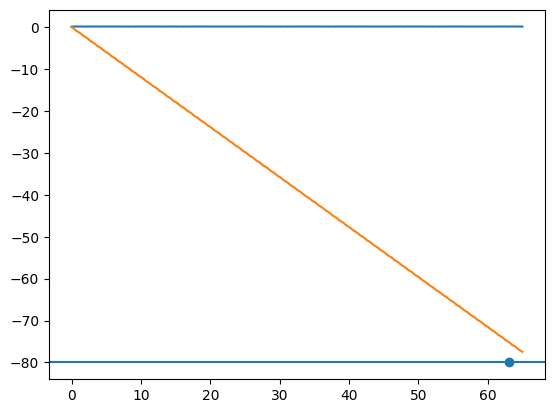

In [4]:
import numpy as np
import matplotlib.pyplot as plt

def xt(x0,y0,xd0,yd0,n,t):
    x = 4*x0 + 2/n*yd0 + np.sin(n*t)/n*xd0 - (3*x0 + 2/n*yd0)*np.cos(n*t)
    return x

def yt(x0,y0,xd0,yd0,n,t):
    y = y0-2/n*xd0 - 3*(2*x0 + yd0/n)*n*t + 2*(3*x0+2/n*yd0)*np.sin(n*t) + 2/n*xd0*np.cos(n*t)
    return y

t = np.linspace(0,5616000,10000)
td = [T/86400 for T in t]
n = 7.3e-5 

# a) x0=0.1
x0 = 0.1
x = xt(x0,0,0,0,n,t)
y = yt(x0,0,0,0,n,t)
# plt.plot(t,x)
# plt.plot(t,y)
# plt.axhline(80)
# plt.axhline(-80)
# plt.scatter(21.3*86400,-80)
# plt.show()


# b) y0=0.1
x0 = 0
y0 = 0.1
yd0 = 0
xd0 = 0
x = xt(x0,y0,xd0,yd0,n,t)
y = yt(x0,y0,xd0,yd0,n,t)
# plt.plot(t,x)
# plt.plot(t,y)
# plt.axhline(80)
# plt.axhline(-80)
# plt.show()


# c) xd0=1e-5
x0 = 0
y0 = 0
yd0 = 0
xd0 = 1e-5
x = xt(x0,y0,xd0,yd0,n,t)
y = yt(x0,y0,xd0,yd0,n,t)
# plt.plot(t,x)
# plt.plot(t,y)
# plt.axhline(80)
# plt.axhline(-80)
# plt.show()

# d) yd0=1e-5
x0 = 0
y0 = 0
yd0 = 1e-5
xd0 = 0
x = xt(x0,y0,xd0,yd0,n,t)
y = yt(x0,y0,xd0,yd0,n,t)
# plt.plot(td,x)
# plt.plot(td,y)
# plt.axhline(80)
# plt.axhline(-80)
# plt.scatter(30.7,-80)
# plt.show()

# e) yd0=1e-5
x0 = 0.1
y0 = 0
yd0 = 1e-5
xd0 = 0
x = xt(x0,y0,xd0,yd0,n,t)
y = yt(x0,y0,xd0,yd0,n,t)
# plt.plot(td,x)
# plt.plot(td,y)
# plt.axhline(80)
# plt.axhline(-80)
# plt.scatter(12.5,-80)
# plt.show()


# f) yd0=-1e-5
x0 = 0.1
y0 = 0
yd0 = -1e-5
xd0 = 0
x = xt(x0,y0,xd0,yd0,n,t)
y = yt(x0,y0,xd0,yd0,n,t)
plt.plot(td,x)
plt.plot(td,y)
plt.axhline(-80)
plt.scatter(63.1,-80)
plt.show()


In [ ]:
import numpy as np
from numpy import sqrt

#########################################################################
# DIMENSIONAL PROBLEM
#########################################################################
vJ = 13 #km/s
rJ = 7.8e8 #km
mu_sun = 1.32e11 #km^3/s^2
mu_J = 1.27e8 #km^3/s^2
RJ = 7e4 #km


# Part a) Find escape velocity and V_infty
print('a: Escape Velocity & V Infinity')
Vesc = sqrt(2)*vJ
print(f'    Relative to sun, V_esc = {round(Vesc,4)} km/s')
V_infty = Vesc-vJ
print(f'    Relative to Jupiter, V_infty = {round(V_infty,4)} km/s')

# Part b) Radius of Periapsis
print('\nb: Radius of Periapsis')
delta = np.pi/2
rp = (np.sin(delta/2)**(-2) - 1)*(mu_J/V_infty**2)
print(f'    r_p = {round(rp*10**(-6),4)} X 10^6 km')
if rp>RJ:
    print('    Satellite will miss jupiter (rp>RJ)')
else:
    print('    Satellite will hit jupiter (rp<RJ)')

# Part c) Vscin, gamma
print('\nc: V_sc_in and Flight Path angle')
Vsc_in = sqrt(vJ**2+V_infty**2)
print(f'    V_sc_in = {round(Vsc_in,4)} km/s')
gamma = np.arctan2(V_infty,vJ)
print(f'    gamma = {round(gamma,4)} rad = {round(gamma*180/np.pi,4)} deg')

# Part d) energy and angular momentum
print('\nd: Energy and Angular Momentum')
energy = 0.5*Vsc_in**2 - mu_sun/rJ   # CHECKED WITH SECOND EQUATION IN PROBLEM 4!!!
print(f'    energy = {round(energy,4)} km^2/s^2')
h = rJ*Vsc_in*np.cos(gamma)          # CHECKED WITH SECOND EQUATION IN PROBLEM 4!!!
print(f'    h = {round(h*10**-10,4)} X 10^10 km^2/s')

# Part e) Orbital Elements in Heliocentric Orbit (pre flyby)
print('\ne: Orbital Elements Before Flyby')
a = -mu_sun/(2*energy)
print(f'    a = {round(a*10**-8,4)} X 10^8 km')
e = sqrt(1-h**2/(mu_sun*a))
print(f'    e = {round(e,4)}')
f = np.arccos(1/e*(a*(1-e**2)/rJ-1))
print(f'    f = {round(f,4)} rad = {round(f*180/np.pi,4)} deg')


# Part extra: Prove J is constant before and after (CHECK)
print('\nChecking results with Tisserand')
n = np.sqrt(mu_sun/a**3)
print(f'    n = {round(n*10**8,4)} X 10^-8 rad/s')
J_in = -mu_sun/(2*a) - n*sqrt(mu_sun*a*(1-e**2))
J_in = energy - n*h
print(f'    J_in = {round(J_in,4)}')
J_out = 1/2*V_infty**2 - n*sqrt(mu_sun*rJ*(1+1))
print(f'    J_out = {round(J_out,4)}')

a: Escape Velocity & V Infinity
    Relative to sun, V_esc = 18.3848 km/s
    Relative to Jupiter, V_infty = 5.3848 km/s

b: Radius of Periapsis
    r_p = 4.3799 X 10^6 km
    Satellite will miss jupiter (rp>RJ)

c: V_sc_in and Flight Path angle
    V_sc_in = 14.0711 km/s
    gamma = 0.3927 rad = 22.5 deg

d: Energy and Angular Momentum
    energy = -70.2329 km^2/s^2
    h = 1.014 X 10^10 km^2/s

e: Orbital Elements Before Flyby
    a = 9.3973 X 10^8 km
    e = 0.4137
    f = 1.5741 rad = 90.1889 deg

Checking results with Tisserand
    n = 1.2612 X 10^-8 rad/s
    J_in = -198.1178
    J_out = -137.6574


In [47]:
import numpy as np
from numpy import sqrt

#########################################################################
# NONDIMENSIONAL PROBLEM
#########################################################################
rJ = 5.2 #AU
vJ = 2*np.pi/sqrt(rJ) #AU/yr
print(f'vJ = {round(vJ,4)} AU/yr')
mu_sun = 4*np.pi**2 #AU^3/yr^2

n = 2*np.pi/rJ**1.5 #rad/yr

Vinfty = sqrt(2)*vJ - vJ
print(f'V_infty = {round(Vinfty,4)} AU/yr')
Jout = 0.5*Vinfty**2 - n*sqrt(mu_sun*rJ*2)
print(f'Juot = {round(Jout,4)}')

h = rJ*vJ
print(f'h = {round(h,4)}')
energy = vJ**2*(2-sqrt(2)) - mu_sun/rJ
print(f'energy = {round(energy,4)}')
Jin = energy - n*h
print(f'Jin = {round(Jin,4)}')

vJ = 2.7554 AU/yr
V_infty = 1.1413 AU/yr
Juot = -10.0854
h = 14.3279
energy = -3.1447
Jin = -10.7367
